# Augmentation

In this notebook we take a closer look at _augmentation_, and test its effect by training a convolutional network.

In [2]:
import os
import tensorflow as tf
import numpy as np
import keras
import matplotlib.pyplot as plt
from PIL import Image

/Users/jakob/Desktop/Jakob/ML/ML_DL-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Data loading and preprocessing

Again we use the cats and dogs dataset:

In [3]:
import os

print(os.getcwd())
print(os.path.exists("../data/raw/PetImages"))
print(os.listdir("../data/raw/PetImages"))

/Users/jakob/Desktop/Jakob/ML/ML_DL-lab/notebooks
True
['Cat', 'Dog']


Skip corrupted images (there are quite a few in this dataset):

In [4]:
def is_clean_jpeg(filepath):
    try:
        with open(filepath, 'rb') as f:
            # Check JPEG header
            header = f.read(2)
            if header != b'\xff\xd8':
                return False
            
            # Try to fully load the image
            f.seek(0)
            img = Image.open(f)
            img.load()
            
            # re-open and verify
            f.seek(0)
            img2 = Image.open(f)
            img2.verify()
            
        return True
    except Exception:
        return False
        
data_dir = "../data/raw/PetImages"
num_corrupted = 0

for root, dirs, files in os.walk(data_dir):
    for filename in files:
        filepath = os.path.join(root, filename)
        if not is_clean_jpeg(filepath):
            num_corrupted += 1
            os.remove(filepath)
            
print(f"Removed {num_corrupted} corrupted files")

/Users/jakob/Desktop/Jakob/ML/ML_DL-lab/.venv/lib/python3.9/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed 0 corrupted files


Load into a TensorFlow dataset, using the Keras utility functions.

If the training is going too slow, you can optionally reduce the dimensions of the images (currently set to 180x180 pixels), and adjust the batch size.

In [5]:
image_shape = (128, 128, 3) # TODO reduce if needed
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "../data/raw/PetImages",
    validation_split=0.2,
    subset="both",
    seed=123,
    shuffle=True,
    image_size=image_shape[:2],
    batch_size=batch_size,
)

Found 24769 files belonging to 2 classes.
Using 19816 files for training.
Using 4953 files for validation.


Pick some example image and show them.

Note that since we set `shuffle=True` in the code cell above, you will see a different image each time you run the cell below. To have the same images each time you can specify `shuffle=False` and have reproducible outputs. For training, however, it's typically better to shuffle the input data.

2026-03-19 19:09:23.634715: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


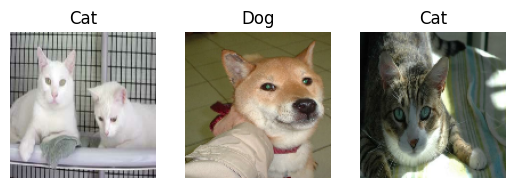

In [6]:
# Select one single batch from the dataset
batch = train_ds.take(1)

plt.figure()

for images, labels in batch:
    for i in range(3):
        ax = plt.subplot(1, 3, i+1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

## Adding augmentations

In Keras, different types of image augmentations are implemented as layers. This means that once instantiated, they can be used as functions that take in an image and gives a transformed image back. In addition, they can be added as part of a model, just like any other kinds of layers.

**Note:** When adding augmentation layers to a model, they should only be active during training, and not during evaluation and inference -- since we don't want to tamper with new images that our finished model is trying to classify. Keras disables the augmentation layers automatically when we run `model.predict()` or `model.evaluate()`.

2026-03-19 19:09:27.763358: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


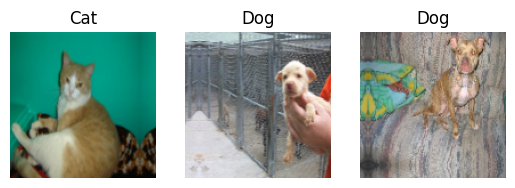

In [7]:
plt.figure()
for images, labels in batch:

    images = keras.layers.RandomTranslation(0.2, 0.2)(images)

    for i in range(3):
        ax = plt.subplot(1, 3, i+1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(train_ds.class_names[int(labels[i])])
        plt.axis("off")

### <span style="color: red; font-weight: bold;">Exercise:<span>

Make the same plots as above, but for all the available augmentation techniques in https://keras.io/api/layers/preprocessing_layers/image_augmentation/.

Put them in a nice layout so that you can compare the effects for each type.

_Hint:_ In case you find it useful to add the augmentation layers in a list and iterate through it, the first element can be a `keras.layers.Identity()` layer, which does nothing except return the original image.

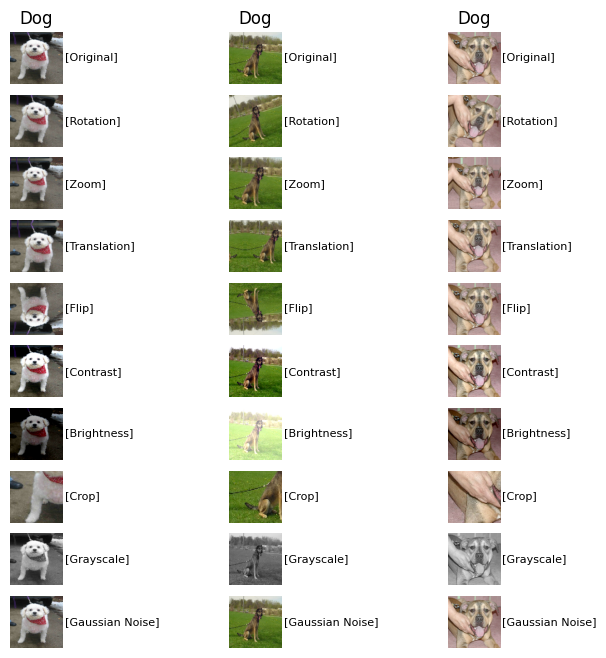

In [10]:
# Your code here
for images, labels in batch:

    augmentations = [
        ("Original", keras.layers.Identity()),
        ("Rotation", keras.layers.RandomRotation(0.1)),
        ("Zoom", keras.layers.RandomZoom(0.5)),
        ("Translation", keras.layers.RandomTranslation(0.1, -0.5)),
        ("Flip", keras.layers.RandomFlip("vertical")),
        ("Contrast", keras.layers.RandomContrast(0.5)),
        ("Brightness", keras.layers.RandomBrightness(0.5)),
        ("Crop", keras.layers.RandomCrop(image_shape[0]//2, image_shape[1]//2)),
        ("Grayscale", keras.layers.RandomGrayscale(1.0)),
        ("Gaussian Noise", keras.layers.GaussianNoise(0.1)),
    ]

    plt.figure(figsize=(8, 8))

    for row, (name, layer) in enumerate(augmentations):

        augmented_images = layer(images)

        for col in range(3):
            ax = plt.subplot(len(augmentations), 3, row * 3 + col + 1)
            plt.imshow(np.array(augmented_images[col]).astype("uint8"))
            if row == 0:
                plt.title(train_ds.class_names[int(labels[col])])
            plt.axis("off")
            ax.text(1.05, 0.5, f"[{name}]", transform=ax.transAxes, fontsize=8, va='center')

## Train some models

Now it is time to put our augmentations to the test.


### Baseline model

For a comparison, let's first train a model with **no** augmentation, on the **full** training dataset (18 728) images.

In [13]:
baseline_model = keras.Sequential(
    [
        keras.Input(shape=image_shape),
        keras.layers.Rescaling(1.0/255),    # Standardise the images
        keras.layers.Conv2D(64, 3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(3, padding='same'),
        keras.layers.Conv2D(64, 3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(3, padding='same'),
        keras.layers.Conv2D(64, 3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:

reduce_lr = keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=0.0001, verbose=1)
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

baseline_model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
 65/620 ━━━━━━━━━━━━━━━━━━━━ 1:31 164ms/step - accuracy: 0.6081 - loss: 0.6863

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


219/620 ━━━━━━━━━━━━━━━━━━━━ 1:06 166ms/step - accuracy: 0.6190 - loss: 0.6633

314/620 ━━━━━━━━━━━━━━━━━━━━ 51s 168ms/step - accuracy: 0.6262 - loss: 0.6535

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


...

598/620 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.7803 - loss: 0.4678

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7802 - loss: 0.4677

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


620/620 ━━━━━━━━━━━━━━━━━━━━ 124s 200ms/step - accuracy: 0.7802 - loss: 0.4677 - val_accuracy: 0.5883 - val_loss: 0.7943 - learning_rate: 0.0010


The final evaluation of the baseline model:

In [15]:
baseline_result = baseline_model.evaluate(val_ds, verbose=0)
print()
print("Accuracy of the baseline model was {}%".format(baseline_result[1]*100))

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9



Accuracy of the baseline model was 75.57036280632019%


## Train on augmented data

Now for the challenge: We **remove** images from the training set, and our task is to match (or maybe even exceed?) the performance of the baseline model.

Let's make the training dataset 2/3 the size.

In [24]:
reduced_train_ds = train_ds.take((2*len(train_ds))//3)
print('train_ds contains', len(train_ds), 'batches (of 32 images each)')
print('reduced_train_ds contains', len(reduced_train_ds), 'batches')

train_ds contains 620 batches (of 32 images each)
reduced_train_ds contains 413 batches


### <span style="color: red; font-weight: bold;">Exercise:<span>

Now, add your favourite augmentation layers to the model:

In [28]:
augmented_model = keras.Sequential(
    [
        # TODO
        # Add augmentation
        keras.Input(shape=image_shape),

        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.25),
        keras.layers.RandomFlip("vertical"),
        keras.layers.RandomBrightness(0.3),
    #    keras.layers.RandomCrop(image_shape[0]//1.1, image_shape[1]//1.1),
        keras.layers.RandomContrast(0.2),

        keras.layers.Rescaling(1.0/255),
        keras.layers.Conv2D(64, 3, kernel_initializer='he_uniform', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(3, padding='same'),
        keras.layers.Conv2D(64, 3, kernel_initializer='he_uniform', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(3, padding='same'),
        keras.layers.Conv2D(64, 3, kernel_initializer='he_uniform', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

augmented_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=0.0001, verbose=1)
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

augmented_model.fit(
    reduced_train_ds,   # use the correct dataset
    epochs=10,
    validation_data=val_ds,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/10
 66/413 ━━━━━━━━━━━━━━━━━━━━ 55s 159ms/step - accuracy: 0.5362 - loss: 0.7269

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


216/413 ━━━━━━━━━━━━━━━━━━━━ 32s 164ms/step - accuracy: 0.5605 - loss: 0.7049

315/413 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.5683 - loss: 0.6962

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


...

357/413 ━━━━━━━━━━━━━━━━━━━━ 14s 253ms/step - accuracy: 0.7142 - loss: 0.5602

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7147 - loss: 0.5593

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


413/413 ━━━━━━━━━━━━━━━━━━━━ 110s 267ms/step - accuracy: 0.7147 - loss: 0.5593 - val_accuracy: 0.6707 - val_loss: 0.6256 - learning_rate: 0.0010


In [37]:
augmented_result = augmented_model.evaluate(val_ds, verbose=0)
print()
print('Accuracy of the augmented model was {:.3f}%'.format(augmented_result[1]*100),
      'vs the baseline model with {:.3f}%'.format(baseline_result[1]*100))
if augmented_result[1] > baseline_result[1]:
    print()
    print('Your model was {:.3f}%'.format(abs(augmented_result[1] - baseline_result[1]) * 100), 'better than the baseline!')
else:
    # Print percentage difference between the two models as absolute value with only 3 decimals
    print()
    print('Your model was off by {:.3f}%'.format(abs(augmented_result[1] - baseline_result[1]) * 100))

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9



Accuracy of the augmented model was 75.409% vs the baseline model with 75.570%

Your model was off by 0.162%


For the finale, train the augmented model on the full dataset!

In [38]:
# Your code here
augmented_model_final= keras.Sequential(
    [
        # Input layer for the augmentation model
        keras.Input(shape=image_shape),

        # Augmentation layers for variations in training the model
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.05),
        keras.layers.RandomZoom(0.15),
        keras.layers.RandomTranslation(0.05, 0.05),
        keras.layers.RandomContrast(0.1),

        # The classification model with the standard architecture including the same convolutional layers as before
        keras.layers.Rescaling(1.0/255),    # Standardise the images
        keras.layers.Conv2D(64, 3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(3, padding='same'),
        keras.layers.Conv2D(64, 3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(3, padding='same'),
        keras.layers.Conv2D(64, 3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

augmented_model_final.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Callbacks in case of lacking progress in training
reduce_lr = keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=0.0001, verbose=1)
early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

augmented_model_final.fit(
    train_ds, epochs=10, validation_data=val_ds, callbacks=[reduce_lr, early_stop]
)

Epoch 1/10
 70/620 ━━━━━━━━━━━━━━━━━━━━ 1:27 160ms/step - accuracy: 0.5381 - loss: 0.7450

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


214/620 ━━━━━━━━━━━━━━━━━━━━ 1:06 164ms/step - accuracy: 0.5733 - loss: 0.7005

323/620 ━━━━━━━━━━━━━━━━━━━━ 49s 168ms/step - accuracy: 0.5845 - loss: 0.6870

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


...

573/620 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 0.8100 - loss: 0.4281

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.8096 - loss: 0.4281

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


620/620 ━━━━━━━━━━━━━━━━━━━━ 168s 271ms/step - accuracy: 0.8096 - loss: 0.4281 - val_accuracy: 0.7103 - val_loss: 0.5633 - learning_rate: 2.0000e-04


In [43]:
full_result = augmented_model_final.evaluate(val_ds, verbose=0)
# Output the accuracy of the augmented model
print('Accuracy of the augmented model: {:.3f}%'.format(full_result[1]*100))
# Output the accuracy of the baseline model
print('Accuracy of the baseline model: {:.3f}%'.format(baseline_result[1]*100))

# Difference
print('Difference: {:.3f}%'.format(abs(full_result[1] - baseline_result[1]) * 100))


Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


Accuracy of the augmented model: 75.268%
Accuracy of the baseline model: 75.570%
Difference: 0.303%


Conclusion:

Baseline-modellen ga høyest validation accuracy. Augmenterte modeller kom svært nær, spesielt når treningssettet ble redusert, men overgikk ikke baseline i dette oppsettet. Dette tyder på at augmentering kan bidra til robusthet og delvis kompensere for mindre datamengde, men at den ikke nødvendigvis gir høyere accuracy når det allerede finnes rikelig med treningsdata.